### **FINANCIAL INCLUSION IN EAST AFRICA**

---

**Objective**
- A model that predicts individuals who are most likely to have or use a bank account.

**Description**
- The dataset contains demographic information and what financial services are used by approximately 33,600 individuals across **East Africa**, spanning the countries: `Kenya, Uganda, Tanzania and Rwanda` from `2016-2018`

---

In [46]:
# import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from ydata_profiling import ProfileReport


In [47]:
# load the dataset
df = pd.read_csv("Financial_inclusion_dataset.csv")
df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


---
**EDA**

---

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


- `13 columns`
- `23,524 rows`

In [49]:
# profile report
profile = ProfileReport(df, title="Financial Inclusion In Africa")
profile.to_file("financial_inclusion.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 134.11it/s]


In [50]:
# handle null values
df.isnull().sum()

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64

- `0 nulls`

In [51]:
# handle duplicates
df.duplicated().sum()

np.int64(0)

- `0 duplicates`

In [52]:
# unique values in country column
print(df['country'].unique())
print(df['year'].unique())

['Kenya' 'Rwanda' 'Tanzania' 'Uganda']
[2018 2016 2017]


Survey Duration: `2016 - 2018`

**4** Countries: `Kenya, Uganda, Tanzania, Rwanda`

In [53]:
# Count occurrences
counts = df['country'].value_counts()

# Convert to percentages
percentages = (counts / counts.sum()) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage(%)': percentages
})
print(result.round(2))

          Count  Percentage(%)
country                       
Rwanda     8735          37.13
Tanzania   6620          28.14
Kenya      6068          25.79
Uganda     2101           8.93


- `Uganda accounts for only ~9%` of the dataset, significantly underrepresented compared to `Rwanda (37%)`, `Tanzania (28%)`, and `Kenya (26%)`, which may skew regional insights toward countries with higher sample sizes


---
**VISUALIZATION**

---

--
*Bank Account Percentage Distribution By Country*


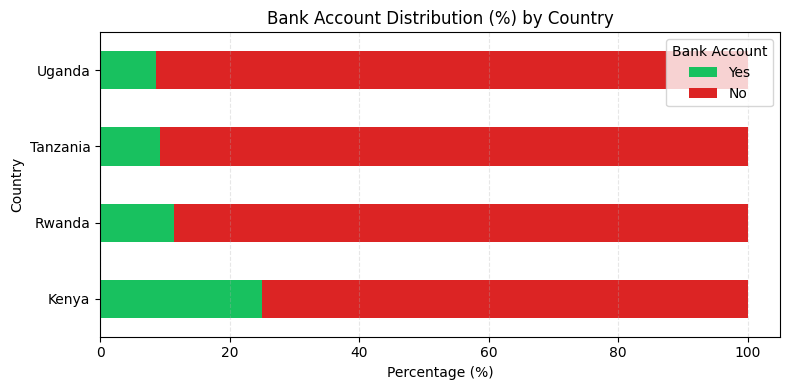

In [54]:
# Bank account distribution by country

df['bank_account'] = pd.Categorical(df['bank_account'], categories=['Yes', 'No'], ordered=True)

# Cross-tabulation
ct = pd.crosstab(df['country'], df['bank_account'])

# Calculate percentages
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100


# Plot
ax = ct_pct.plot(kind='barh', stacked=True, figsize=(8, 4), color=["#18c15f", "#dc2424"])

plt.title('Bank Account Distribution (%) by Country')
plt.xlabel('Percentage (%)')
plt.ylabel('Country')
plt.legend(title='Bank Account', loc='upper right')

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Kenya shows a relatively higher rate of bank account ownership (~23%) compared to other countries, while Uganda, despite being underrepresented in the dataset, demonstrates comparable inclusion levels.
---


*-- Cellphone Access vs Bank Account Ownership by Country (%)*

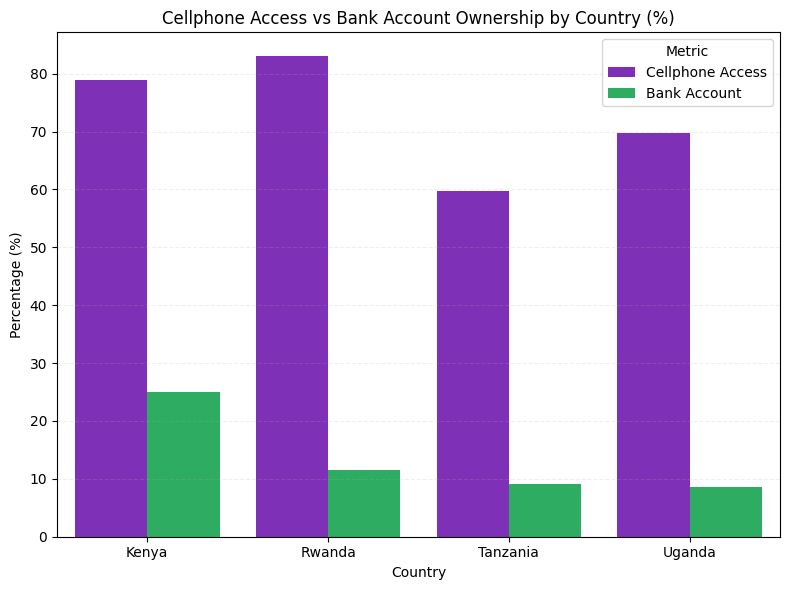

In [55]:
# Cellphone Access vs Bank Account Ownership by Country (%)

# Crosstabs 
cellphone_crosstab = pd.crosstab(df['country'], df['cellphone_access'])
bank_crosstab = pd.crosstab(df['country'], df['bank_account'])

# Ensure column order is consistent
cellphone_crosstab = cellphone_crosstab[['Yes', 'No']]
bank_crosstab = bank_crosstab[['Yes', 'No']]

# Convert to %
cellphone_pct = cellphone_crosstab.div(cellphone_crosstab.sum(axis=1), axis=0) * 100
bank_pct = bank_crosstab.div(bank_crosstab.sum(axis=1), axis=0) * 100

# Extract "Yes" percentages and reset index
cellphone_yes = cellphone_pct['Yes'].reset_index(name='cellphone_pct')
bank_yes = bank_pct['Yes'].reset_index(name='bank_pct')

# Merge
comparison = pd.merge(cellphone_yes, bank_yes, on='country')

# Reshape
comparison_melted = comparison.melt(
    id_vars='country',
    value_vars=['cellphone_pct', 'bank_pct'],
    var_name='Type',
    value_name='Percentage'
)

comparison_melted['Type'] = comparison_melted['Type'].replace({
    'cellphone_pct': 'Cellphone Access',
    'bank_pct': 'Bank Account'
})

# Plot
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=comparison_melted,
    x='country',
    y='Percentage',
    hue='Type',
    palette=["#8219cd", "#18c15f"]
)

plt.title('Cellphone Access vs Bank Account Ownership by Country (%)')
plt.xlabel('Country')
plt.ylabel('Percentage (%)')

plt.legend(title='Metric', loc="upper right")
ax.grid(axis='y', linestyle='--', alpha=0.2)    

plt.tight_layout()
plt.show()

- *Cellphone access* is high across all countries *(60–83%)*, but *bank account ownership* remains much lower *(9–25%)*. 
Kenya has the highest banking rate, while Rwanda shows the largest gap between access and inclusion. This suggests that *widespread mobile access does not necessarily translate into financial inclusion*.

---

*-- Bank Account Distribution YoY(%)*

Bank Account Distribution by Year:
bank_account   Yes    No
year                    
2016          1003  7732
2017           607  6013
2018          1702  6467


C:\Users\Crystal\AppData\Local\Temp\ipykernel_20036\3247120550.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['year', 'bank_account']).size().unstack()


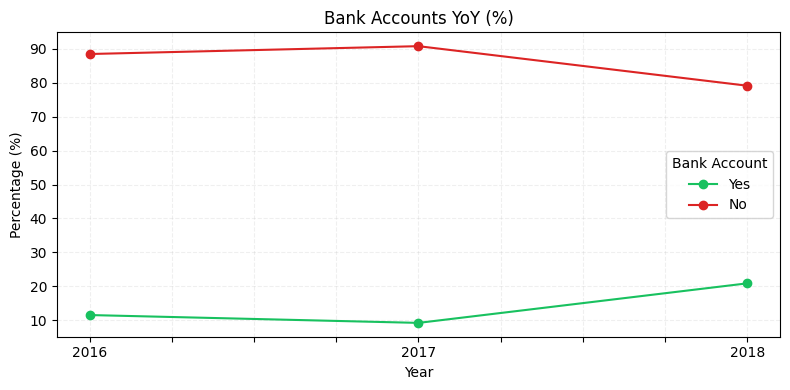

In [56]:
# Count bank accounts by year
# cross-tabulation
cross_tab = pd.crosstab(df['year'], df['bank_account'])
print("Bank Account Distribution by Year:")
print(cross_tab)

# Convert 'year' to categorical for better plotting(without the resulting chart is sorted by quarter
# instead of year)
df['year'] = df['year'].astype('category')

# percentage
counts = df.groupby(['year', 'bank_account']).size().unstack()
counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100

# plot
ax = counts_pct.plot(marker='o', figsize=(8,4), color=["#18c15f", "#dc2424"])

plt.title("Bank Accounts YoY (%)")
plt.xlabel("Year")
plt.ylabel("Percentage (%)")
plt.legend(title="Bank Account")

ax.grid(axis='both', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

- Over the years, there is an increase in the number of people who have a bank account. However, the count of individuals without is still relatively high in comparison.
---

*-- Bank Account Distribution (%) by Location*

Bank Account Distribution by Location:
bank_account    Yes     No
location_type             
Rural          1671  12672
Urban          1641   7540


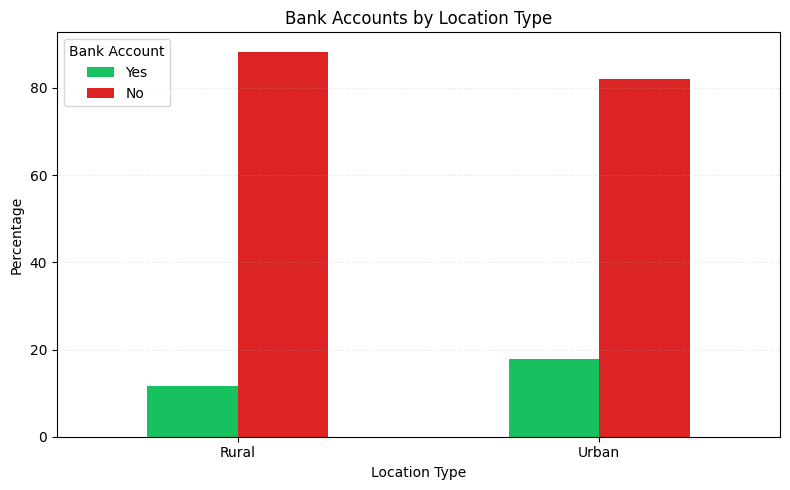

In [57]:
# location vs bank account
location_crosstab = pd.crosstab(df['location_type'], df['bank_account'])
print("Bank Account Distribution by Location:")
print(location_crosstab)

lcp = location_crosstab.div(location_crosstab.sum(axis=1), axis=0) * 100

ax = lcp.plot(kind='bar', figsize=(8, 5), color=["#18c15f", "#dc2424"])

plt.title("Bank Accounts by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Percentage")
plt.legend(title="Bank Account")
plt.xticks(rotation=0)

ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

- Bank account ownership is higher in urban areas (~18%) compared to rural areas (~12%). Despite this, the majority of individuals in both locations remain unbanked, with rural areas showing the lowest levels of financial inclusion.

---


*-- Bank Account Distribution (%) by Gender*

Bank Account Distribution by Gender:
bank_account           Yes     No
gender_of_respondent             
Female                1482  12395
Male                  1830   7817


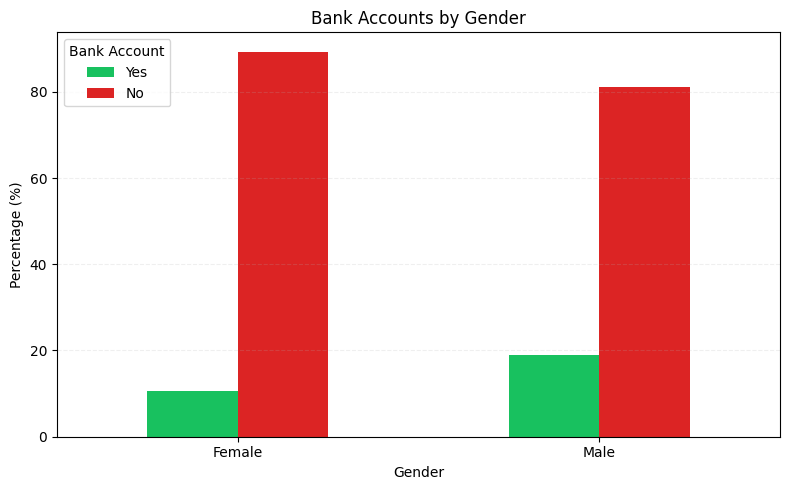

In [58]:
# Gender vs bank account
gender_crosstab = pd.crosstab(df['gender_of_respondent'], df['bank_account'])
print("Bank Account Distribution by Gender:")
print(gender_crosstab)

gcp = gender_crosstab.div(gender_crosstab.sum(axis=1), axis=0) * 100

#plot
ax = gcp.plot(kind='bar', figsize=(8, 5), color=["#18c15f", "#dc2424"])

plt.title("Bank Accounts by Gender")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.ylabel("Percentage (%)")
plt.legend(title="Bank Account")

ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

- Although females make up a larger proportion of the dataset, males exhibit a higher bank account ownership rate (19% vs 11%). This suggests a clear gender disparity in financial inclusion, with women being nearly half as likely to have a bank account as men.

---
**FEATURE ENGINEERING**

---

*-- Handle outliers*

In [59]:
# handle outliers
# Define numerical columns with their minimum allowed values
num_cols = {
    'age_of_respondent': 18, # minimum age to have a bank account
    'household_size': 1 # minimum number of peoplr in a household
}

def clip_outliers(df):
    for col, min_val in num_cols.items():
        # Calculate IQR bounds
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Calculate bounds with minimum enforcement
        lower = max(Q1 - 1.5 * IQR, min_val)  # Ensures minimum value
        upper = Q3 + 1.5 * IQR
        
        # Count outliers (values outside bounds)
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        
        # Print stats
        print(f"\nColumn: {col}")
        print(f"Calculated lower bound: {Q1 - 1.5 * IQR:.2f}")
        print(f"Enforced lower bound: {lower:.2f}")
        print(f"Upper bound: {upper:.2f}")
        print(f"Number of outliers: {n_outliers}")
        
        # Clip values to enforced bounds
        df[col] = df[col].clip(lower=lower, upper=upper)
    
    return df

# Apply to dataframe
df = clip_outliers(df)

# Show final statistics
print("\nFinal statistics after clipping:")
print(df[list(num_cols.keys())].describe())


Column: age_of_respondent
Calculated lower bound: -8.50
Enforced lower bound: 18.00
Upper bound: 83.50
Number of outliers: 1180

Column: household_size
Calculated lower bound: -2.50
Enforced lower bound: 1.00
Upper bound: 9.50
Number of outliers: 381

Final statistics after clipping:
       age_of_respondent  household_size
count       23524.000000    23524.000000
mean           38.811788        3.770894
std            16.283876        2.138426
min            18.000000        1.000000
25%            26.000000        2.000000
50%            35.000000        3.000000
75%            49.000000        5.000000
max            83.500000        9.500000


In [60]:
df.drop(columns='uniqueid', inplace=True)

*-- Encoding*

In [61]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Categorical columns to encode
categorical_cols = [
    'country',
    'location_type',
    'cellphone_access',
    'gender_of_respondent',
    'relationship_with_head',
    'marital_status',
    'education_level',
    'job_type'
]

# Binary Columns (Label Encoding)
binary_cols = ['cellphone_access', 'gender_of_respondent']

# Store encoders for Streamlit
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoder

# Nominal Columns (OneHot Encoding)
nominal_cols = ['country', 'location_type', 'relationship_with_head', 
                'marital_status', 'job_type']

# Initialize and save OneHotEncoder
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_nominal = onehot_encoder.fit_transform(df[nominal_cols])

# Create DataFrame for encoded features
encoded_df = pd.DataFrame(
    encoded_nominal,
    columns=onehot_encoder.get_feature_names_out(nominal_cols)
)

# Drop original nominal columns and concatenate encoded ones
df = df.drop(columns=nominal_cols)
df = pd.concat([df, encoded_df], axis=1)


# Ordinal Columns (Manual Mapping for Education Level)
education_order = {
    'No formal education': 0,
    'Primary education': 1,
    'Secondary education': 2,
    'Vocational/Specialised training': 3,
    'Tertiary education': 4,
    'Other/Dont know/RTA': 0  # Handle unknowns as lowest tier
}
df['education_level'] = df['education_level'].map(education_order)


# Verify Encoding
print("\nEncoded Data Sample:")
print(df.head())

print("\nEncoded Columns:")
print(df.columns)


Encoded Data Sample:
   year bank_account  cellphone_access  household_size  age_of_respondent  \
0  2018          Yes                 1             3.0               24.0   
1  2018           No                 0             5.0               70.0   
2  2018          Yes                 1             5.0               26.0   
3  2018           No                 1             5.0               34.0   
4  2018           No                 0             8.0               26.0   

   gender_of_respondent  education_level  country_Rwanda  country_Tanzania  \
0                     0                2             0.0               0.0   
1                     0                0             0.0               0.0   
2                     1                3             0.0               0.0   
3                     0                1             0.0               0.0   
4                     1                1             0.0               0.0   

   country_Uganda  ...  marital_status_Widowed

---
**TRAIN MODEL**

---

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [63]:
# define features and target variable
X = df.drop('bank_account', axis=1)
y = df['bank_account']

In [64]:
# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

*-- Handle Imbalance*

In [65]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE to oversample the minority class in the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)


*-- Train using Random Forest Algorithm*

In [66]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_res, y_res)
y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.855047821466525

In [67]:
from sklearn.model_selection import RandomizedSearchCV

# Define the Random Forest Classifier and parameter distribution
rf = RandomForestClassifier(random_state=42)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# RandomizedSearchCV for efficient hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,          # Number of parameter combinations to try
    cv=5,               # 5-fold cross-validation
    n_jobs=-1,          # Use all available processors
    random_state=42
)

# Fit the model
random_search.fit(X_res, y_res)

# Get the best parameters and score
best_params = random_search.best_params_
best_score = random_search.best_score_

# Display the results
print("Best parameters:", best_params)
print("Best score:", best_score)


Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 30}
Best score: 0.9116068442190969


*-- Save model*

In [68]:
# Save for Streamlit
import joblib

joblib.dump({
    'label_encoders': label_encoders,      # For binary columns
    'onehot_encoder': onehot_encoder,      # For nominal features
    'education_mapping': education_order,  # For education levels
    'feature_names': X.columns.tolist()    # For feature order validation
}, 'preprocessing_artifacts.pkl')

['preprocessing_artifacts.pkl']

In [69]:
# exporting the model

joblib.dump(random_search, "model.pkl")

['model.pkl']